## Visualize results of `compute_precip_stats.py`

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

In [7]:
files = ["../evals/precip_stats_multilevel.nc", "../evals/precip_stats_multilevel.ref.nc"]
random_baseline_file = "../evals/precip_stats_multilevel.random_ref.nc"

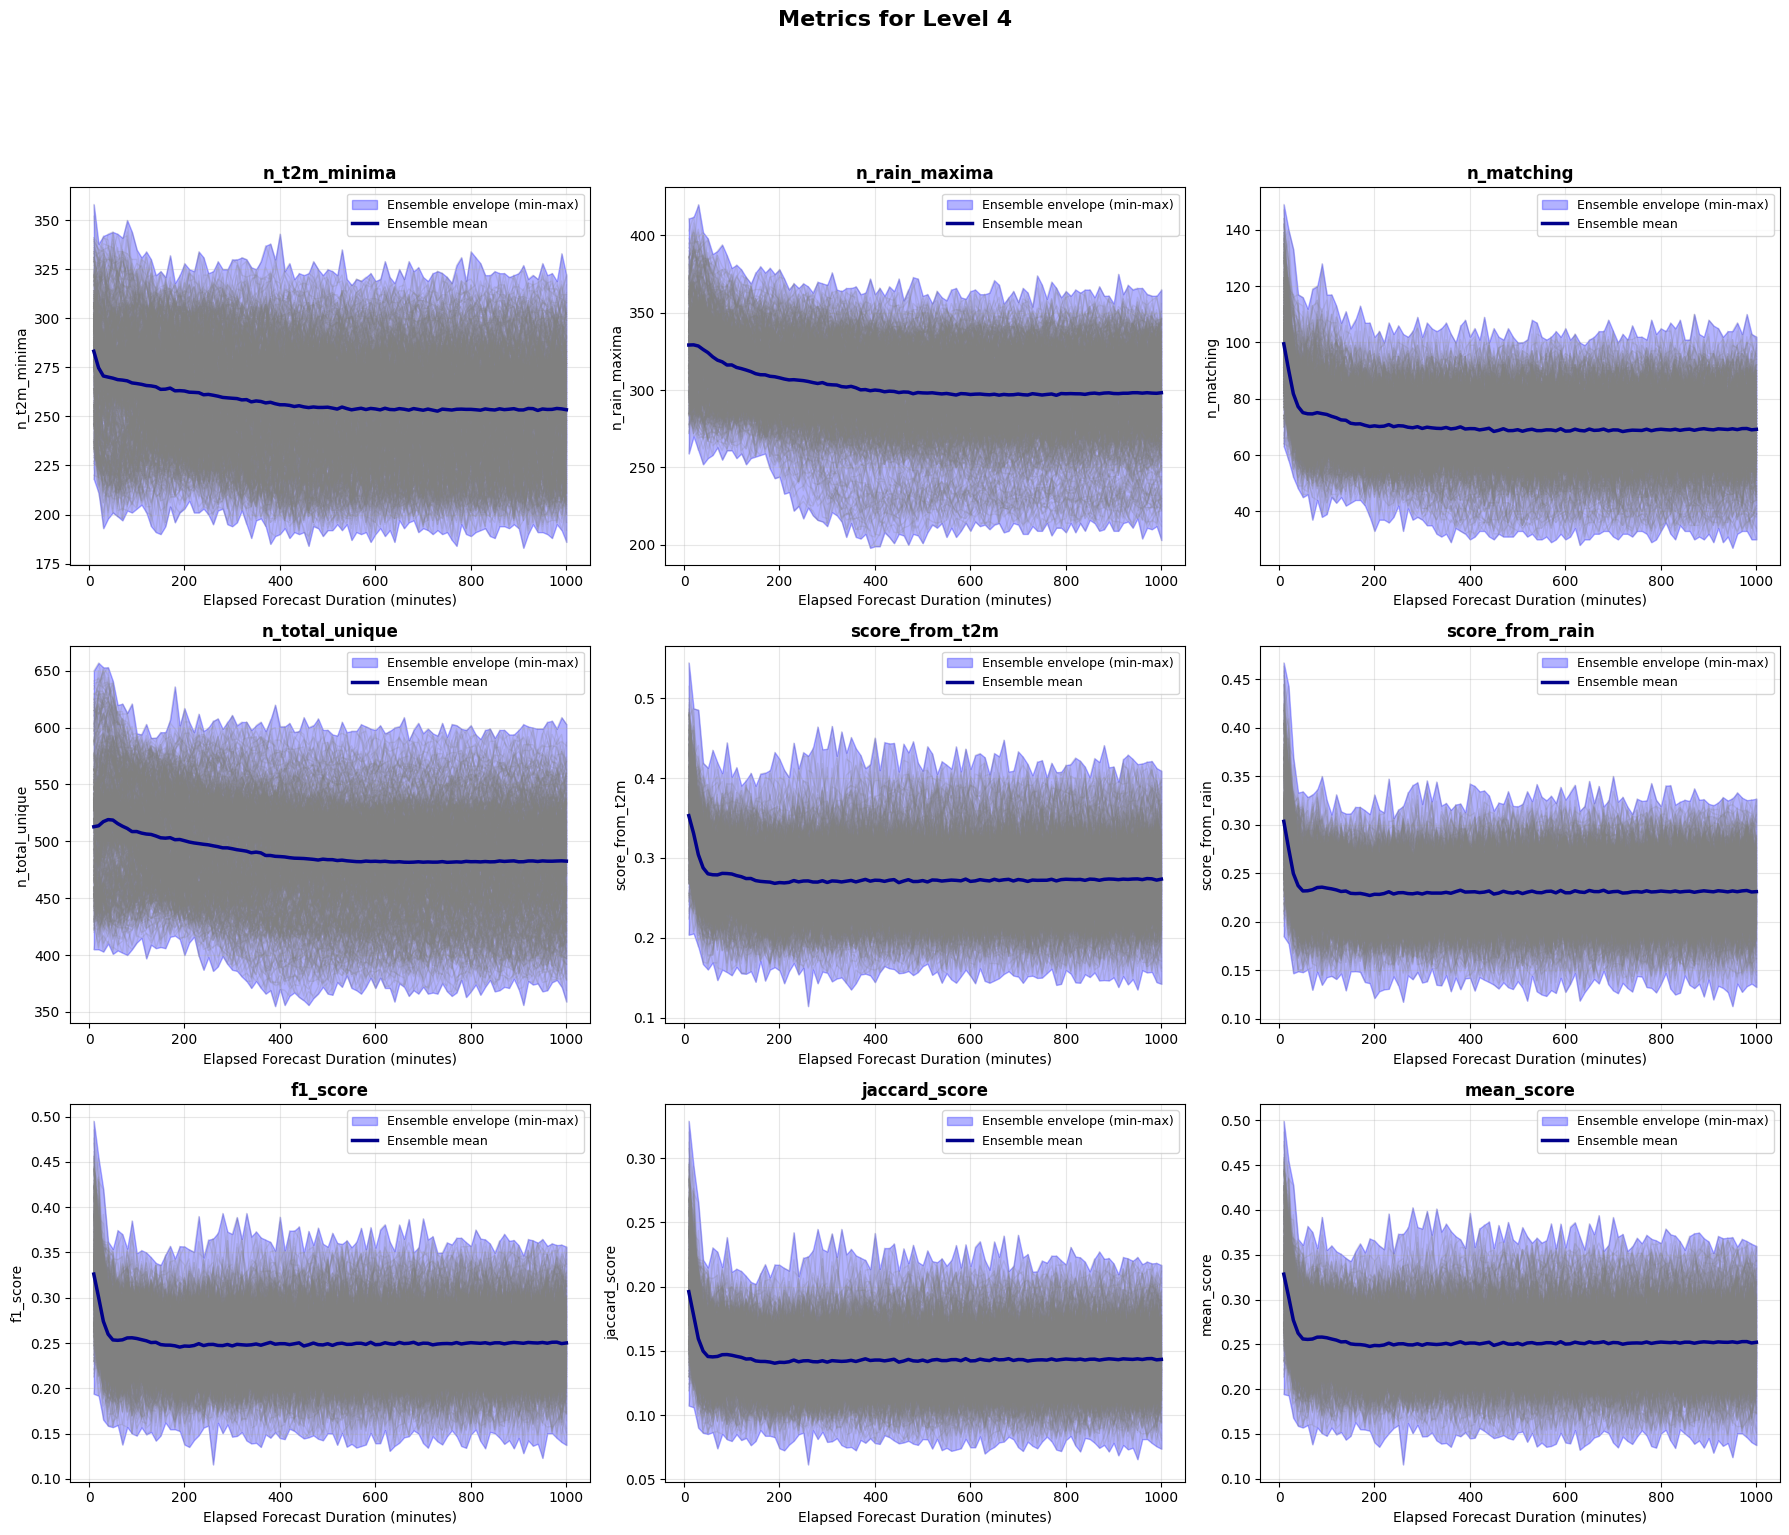

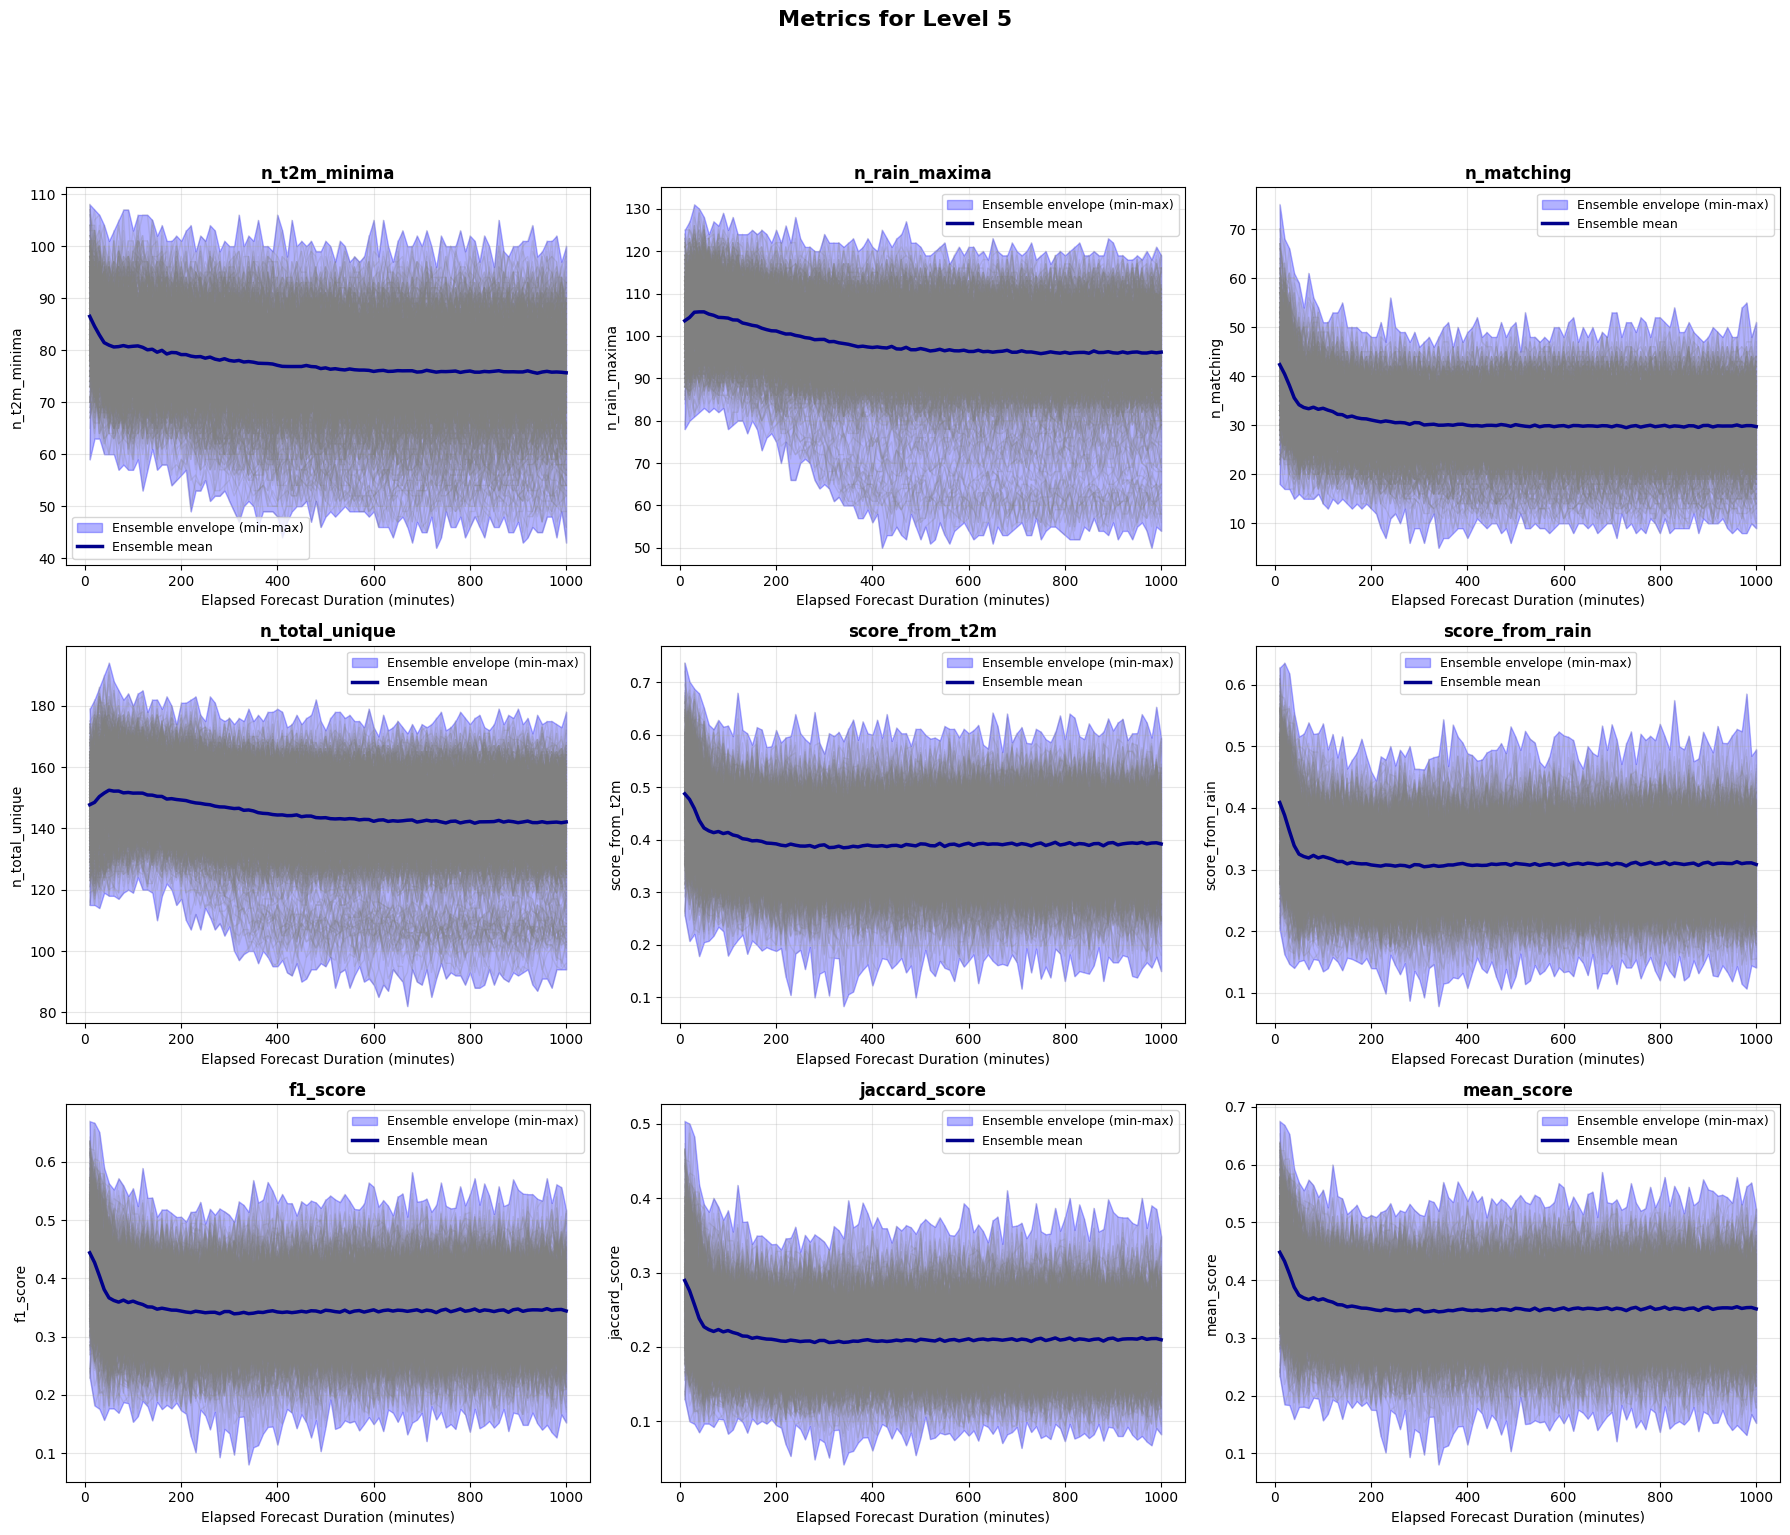

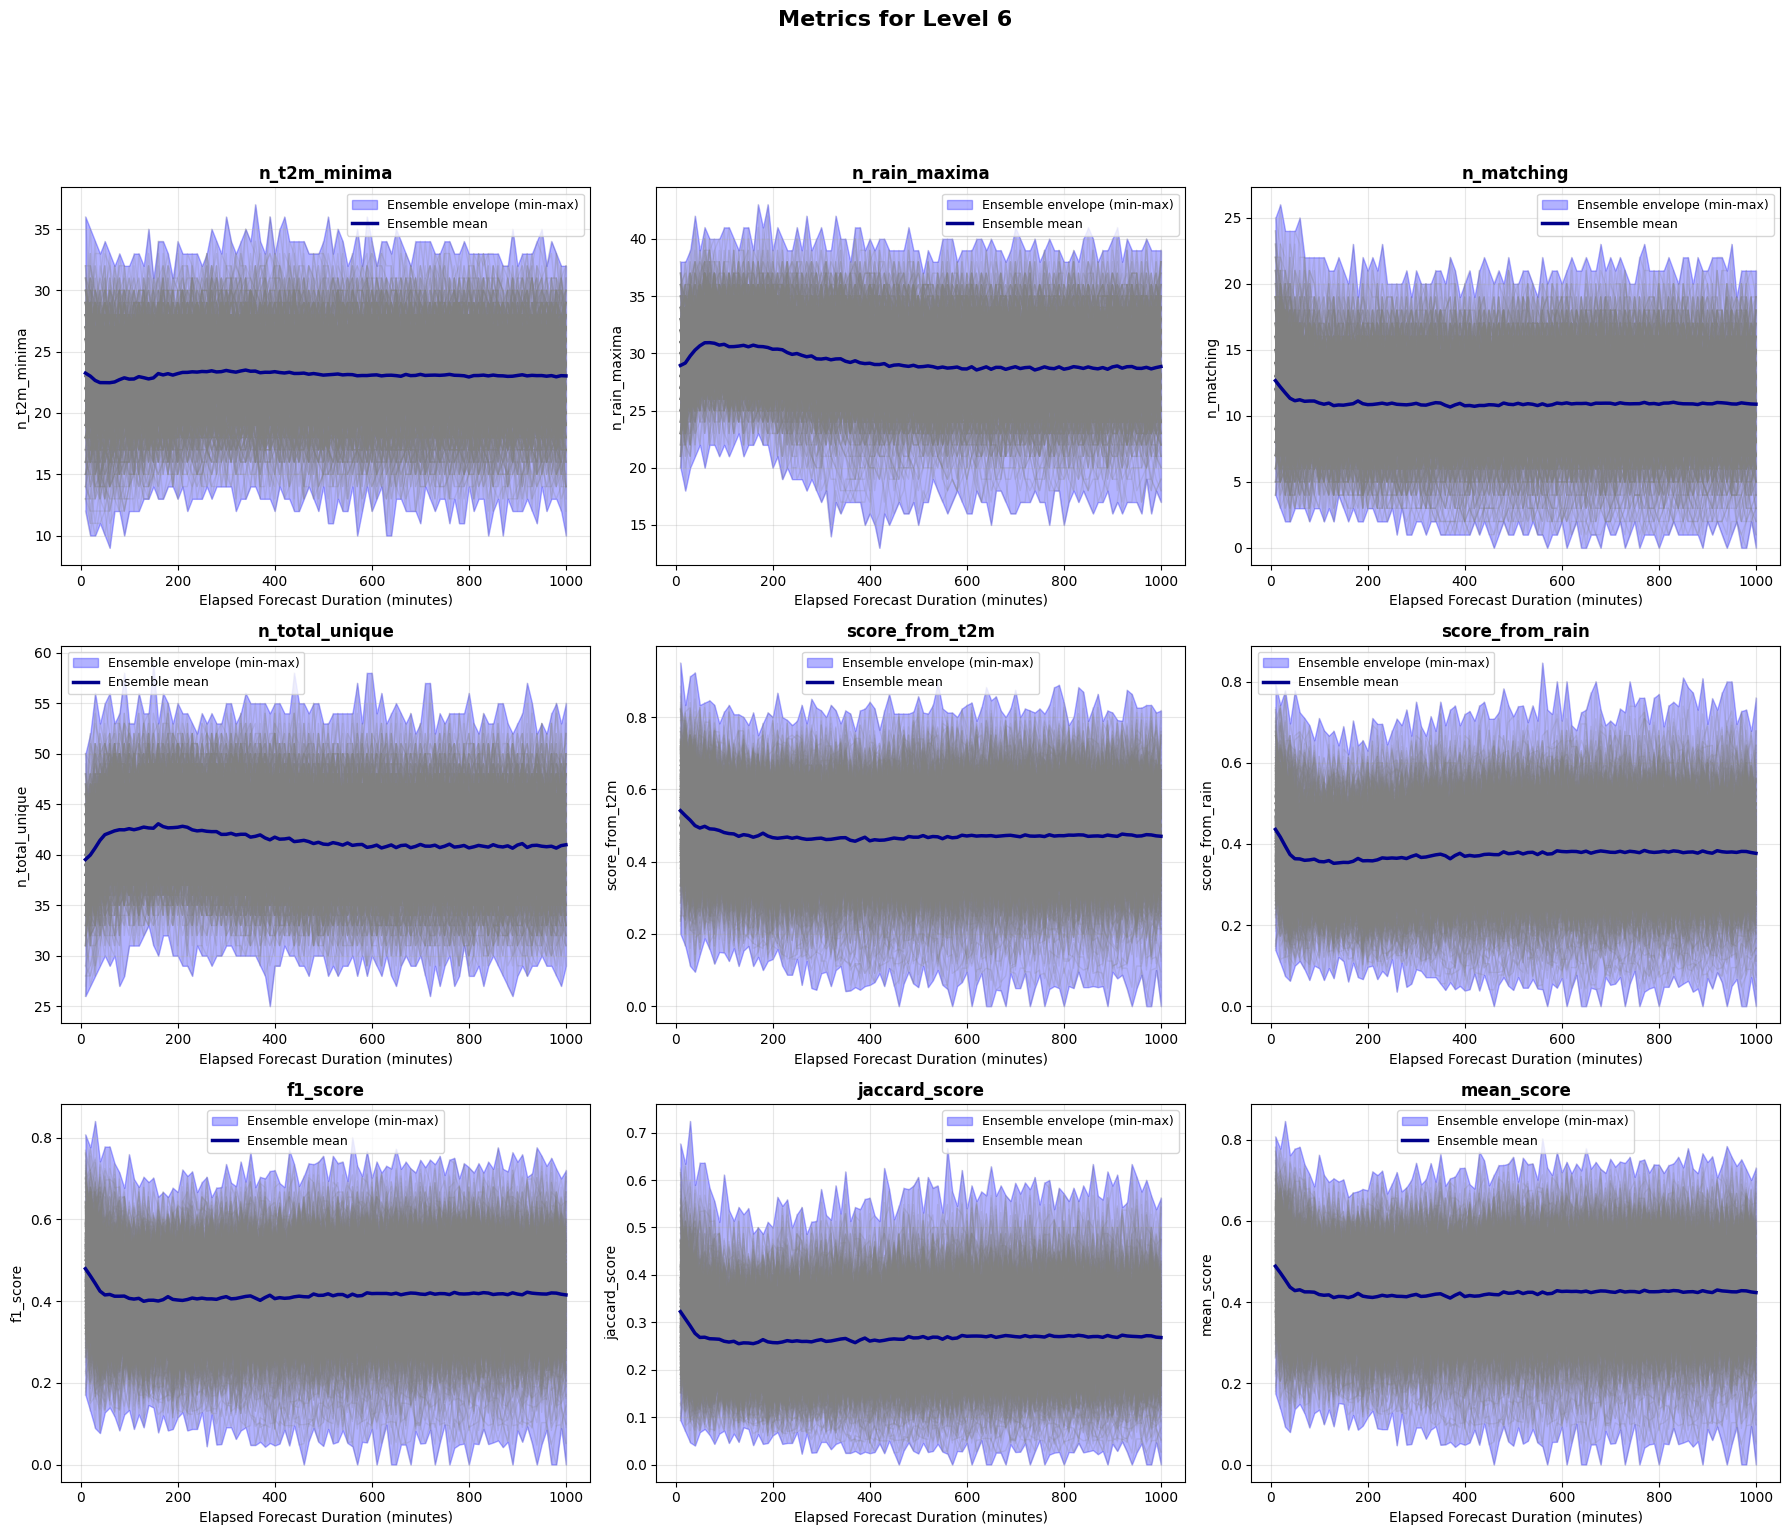

In [ ]:
for file in files:
    metrics_ds_all_levels = xr.open_dataset(file).drop_duplicates('start_time')
    metrics_ds_all_levels
    for level in metrics_ds_all_levels['level'].values:
        metrics_ds = metrics_ds_all_levels.sel(level=level)
        # Create ensemble plots for all metrics
        metrics_to_plot = [var for var in metrics_ds.data_vars if var not in ['start_time']]

        n_metrics = len(metrics_to_plot)
        n_cols = 3
        n_rows = (n_metrics + n_cols - 1) // n_cols

        fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
        axes = axes.flatten()  # Flatten to 1D array for easier indexing

        for idx, metric in enumerate(metrics_to_plot):
            ax = axes[idx]
            
            # Extract metric data
            metric_data = metrics_ds[metric]
            
            # Calculate mean across all dimensions except elapsed_forecast_duration and start_time
            mean_by_duration_and_starttime = metric_data.mean(dim=[d for d in metric_data.dims 
                                                                    if d not in ['elapsed_forecast_duration', 'start_time']])
            
            # Calculate the ensemble mean across start_times
            ensemble_mean_metric = mean_by_duration_and_starttime.mean(dim='start_time')
            
            # Calculate min/max envelope across start_times for each duration
            ensemble_min_metric = mean_by_duration_and_starttime.min(dim='start_time')
            ensemble_max_metric = mean_by_duration_and_starttime.max(dim='start_time')
            
            # Convert elapsed_forecast_duration to hours (numeric)
            elapsed_durations_metric = (ensemble_mean_metric['elapsed_forecast_duration'].values.astype('timedelta64[m]').astype(float))
            
            # Plot ensemble envelope (shaded area)
            ax.fill_between(elapsed_durations_metric, ensemble_min_metric.values, ensemble_max_metric.values, 
                            alpha=0.3, color='blue', label='Ensemble envelope (min-max)')
            
            # Plot individual start_time curves (light gray)
            for start_time in mean_by_duration_and_starttime['start_time'].values:
                ax.plot(elapsed_durations_metric, 
                        mean_by_duration_and_starttime.sel(start_time=start_time).values,
                        color='gray', alpha=0.2, linewidth=1)
            
            # Plot ensemble mean
            ax.plot(elapsed_durations_metric, ensemble_mean_metric.values, 
                    color='darkblue', linewidth=2.5, label='Ensemble mean', zorder=5)
            
            # Formatting
            ax.set_xlabel('Elapsed Forecast Duration (minutes)', fontsize=10)
            ax.set_ylabel(metric, fontsize=10)
            ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9, loc='best')

        # Hide unused subplots
        for idx in range(len(metrics_to_plot), len(axes)):
            axes[idx].set_visible(False)

        plt.suptitle(f'Metrics for Level {level}', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

## Direct comparison between reference and prediction

In [13]:
ds = xr.open_mfdataset(files + [random_baseline_file], concat_dim='dataset', combine='nested')

In [14]:
ds

<xarray.Dataset> Size: 18MB
Dimensions:                    (dataset: 3, level: 4, start_time: 1043,
                                elapsed_forecast_duration: 20)
Coordinates:
  * level                      (level) int64 32B 3 4 5 6
  * start_time                 (start_time) datetime64[ns] 8kB 2020-02-12T00:...
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 160B ...
Dimensions without coordinates: dataset
Data variables:
    n_t2m_minima               (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    n_rain_maxima              (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    n_matching                 (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    n_total_unique             (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    score_from_t2m             (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    score_from_rain            (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    f1_score                   (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    jaccard_score              (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>
    mean_score                 (dataset, level, start_time, elapsed_forecast_duration) float64 2MB dask.array<chunksize=(1, 4, 1043, 20), meta=np.ndarray>

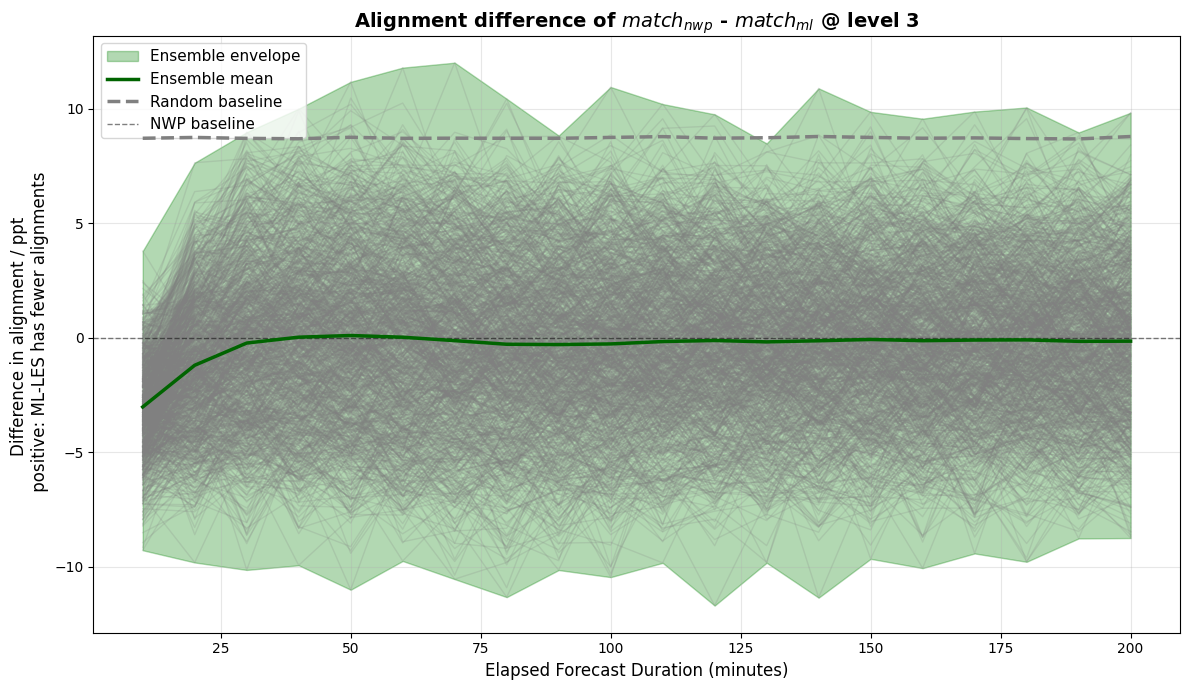

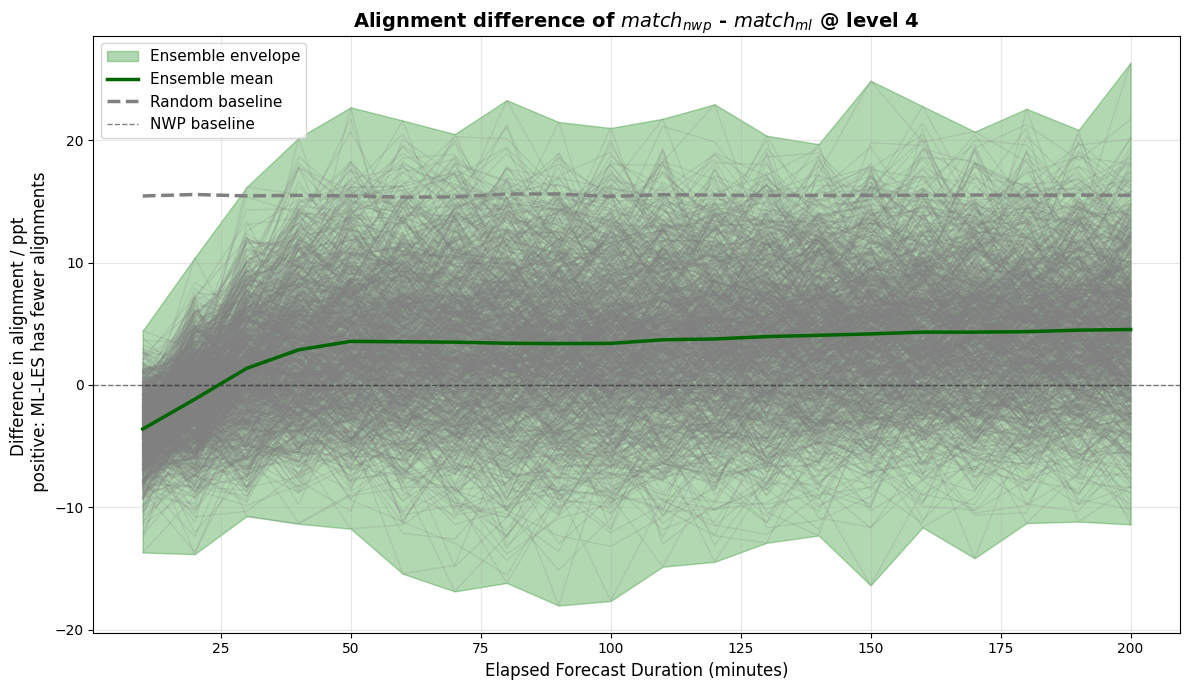

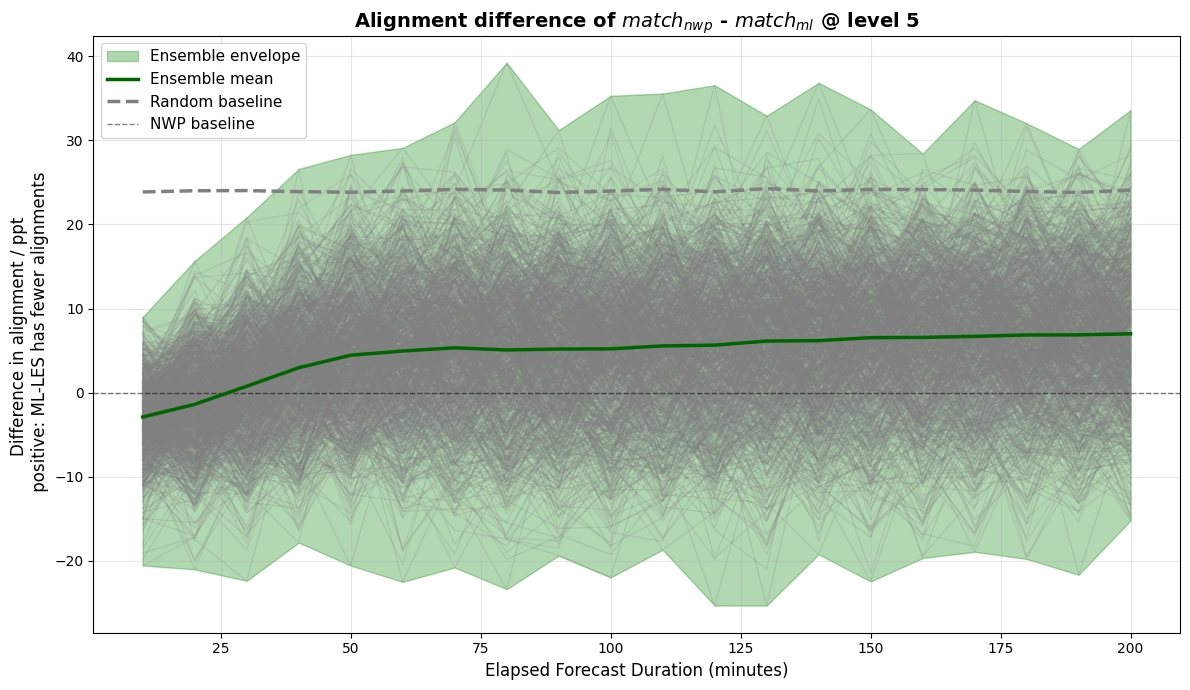

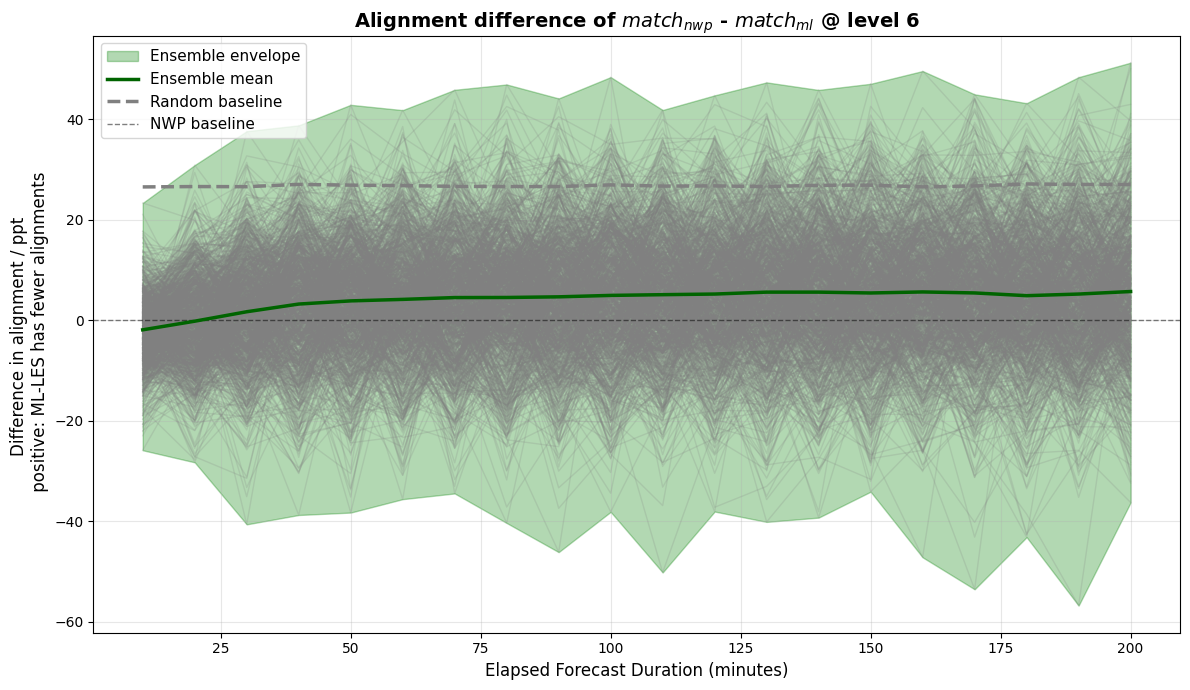

In [15]:
for level in ds['level'].values:
    diff = (ds.mean_score.isel(dataset=1) - ds.mean_score.isel(dataset=0)).sel(level=level)*100
    diff_random = (ds.mean_score.isel(dataset=1) - ds.mean_score.isel(dataset=2)).sel(level=level)*100

    # Calculate mean across all dimensions except elapsed_forecast_duration and start_time
    mean_diff = diff

    # Calculate the ensemble mean across start_times
    ens_mean = mean_diff.mean(dim='start_time')
    ens_min = mean_diff.min(dim='start_time')
    ens_max = mean_diff.max(dim='start_time')

    random_mean = diff_random.mean(dim='start_time')
    
    # Get n_matching from first dataset
    n_matching_ds0 = ds.n_matching.isel(dataset=0).sel(level=level)
    n_matching_mean = n_matching_ds0.mean(dim='start_time')
    n_t_min_mean = ds.n_t2m_minima.isel(dataset=0).sel(level=level).mean(dim='start_time')
    n_rr_max_mean = ds.n_rain_maxima.isel(dataset=0).sel(level=level).mean(dim='start_time')

    n_matching_ds0_ml = ds.n_matching.isel(dataset=1).sel(level=level)
    n_matching_mean_ml = n_matching_ds0_ml.mean(dim='start_time')
    n_t_min_mean_ml = ds.n_t2m_minima.isel(dataset=1).sel(level=level).mean(dim='start_time')
    n_rr_max_mean_ml = ds.n_rain_maxima.isel(dataset=1).sel(level=level).mean(dim='start_time')

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Convert elapsed_forecast_duration to minutes
    elapsed_dur = ens_mean['elapsed_forecast_duration'].values.astype('timedelta64[m]').astype(float)

    # Plot ensemble envelope
    ax.fill_between(elapsed_dur, ens_min.values, ens_max.values, alpha=0.3, color='green', label='Ensemble envelope')

    # Plot individual curves
    for st in mean_diff['start_time'].values:
        ax.plot(elapsed_dur, mean_diff.sel(start_time=st).values, color='gray', alpha=0.2, linewidth=1)

    # Plot ensemble mean
    ax.plot(elapsed_dur, ens_mean.values, color='darkgreen', linewidth=2.5, label='Ensemble mean', zorder=5)

    # Plot random baseline mean
    ax.plot(elapsed_dur, random_mean.values, color='grey', linewidth=2.5, label='Random baseline', zorder=60, linestyle='--')

    # Add zero line
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='NWP baseline')

    # Formatting
    ax.set_xlabel('Elapsed Forecast Duration (minutes)', fontsize=12)
    ax.set_ylabel('Difference in alignment / ppt \n positive: ML-LES has fewer alignments', fontsize=12)
    ax.set_title(f'Alignment difference of $match_{{nwp}}$ - $match_{{ml}}$ @ level {level}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='upper left')
    
    # # Create second y-axis for n_matching
    # ax2 = ax.twinx()
    # ax2.plot(elapsed_dur, n_matching_mean.values, color='orange', linewidth=2, 
    #          linestyle='-', label='n_matching (NWP)', zorder=3)
    # ax2.plot(elapsed_dur, n_rr_max_mean.values, color='blue', linewidth=2, 
    #          linestyle='-', label='n_rain_maxima (NWP)', zorder=3)
    # ax2.plot(elapsed_dur, n_t_min_mean.values, color='brown', linewidth=2,
    #          linestyle='-', label='n_t2m_minima (NWP)', zorder=3)
    # ax2.plot(elapsed_dur, n_t_min_mean_ml.values, color='brown', linewidth=2,
    #          linestyle='--', label='n_t2m_minima (ML)', zorder=3)
    # ax2.plot(elapsed_dur, n_rr_max_mean_ml.values, color='blue', linewidth=2,
    #          linestyle='--', label='n_rain_maxima (ML)', zorder=3)
    # ax2.plot(elapsed_dur, n_matching_mean_ml.values, color='orange', linewidth=2,
    #          linestyle='--', label='n_matching (ML)', zorder=3)
    # ax2.set_ylabel('n_matching (count)', fontsize=12, color='orange')
    # ax2.tick_params(axis='y', labelcolor='orange')
    # ax2.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.show()